# Jupyter - Day 5 - Section 002
## Lecture 5 - Assessing Coefficient Accuracy

In the today's lectures, we are starting focused on simple linear regression, that is, fitting models of the form 

$$
Y =  \beta_0 +  \beta_1 X_1 + \varepsilon
$$

In this lab, we will use two different tools for linear regression. 
- [Scikit learn](https://scikit-learn.org/stable/index.html) is arguably the most used tool for machine learning in python 
- [Statsmodels](https://www.statsmodels.org) provides many of the statisitcial tests we've been learning in class

In [1]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

# Importing the Linear Regression we learned last time from sklearn
from sklearn.linear_model import LinearRegression

##ANSWER##

*Instructor notes:* This might be better to switch orders, so multi-variable introduced and then just one discussion of evaluating the models (single and multi together at once).  This partially happened because in 2022 the previous class was done online due to Liz being sick.  It's possible maybe all of 3.1 could have been done in one day, but for now i'm sticking with this order to not have to redo too much. 

# Simulating data 
Ok, let's run an example like was shown in class where we see the distribution of possible values. 

In [2]:
# Here's code that decides on my function 
def myFunc(x, b0=2, b1=5): 
    return b0 + b1*x


# Here's a command that generates 100 random data points from f(x) + epsilon
def makeData(n = 100):
    X = np.random.uniform(-2,2,n)
    y = myFunc(X) + np.random.normal(size = n)
    return X,y

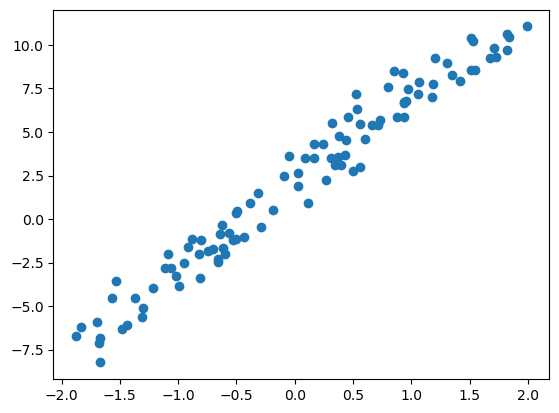

In [3]:
# Everytime you run this cell, you get slightly different data

X,y = makeData()

plt.scatter(X,y)

In [4]:
# Which means that every time you run this cell, you get a slightly different choice of coefficients
# for the model learned

X,y = makeData()
X = X.reshape([len(X),1])
y = y.reshape([len(y),1])
reg = LinearRegression()
reg.fit(X,y)
print( 'y = '+ str(round(reg.intercept_[0],4)) +' + ' + str(round(reg.coef_[0,0],4)) +  " * x_1"  )


y = 2.0121 + 4.9468 * x_1


&#9989; **<font color=red>Q:</font>** 
If we assume that our data is coming from the setting 

$$
Y = f(X) + \varepsilon
$$

what is $\mathrm{Var}(\varepsilon)$?

*Your answer here*

##ANSWER##

Because the noise is drawn from a normal distribution which has a default setting of std = 1, this means $\mathrm{Var}(\varepsilon) = 1^2 = 1$. 

In [5]:
# So now, lets just train our linear model lots of times, and collect the resulting coefficients

beta0_list = []
beta1_list = []
for i in range(100):
    X,y = makeData()
    X = X.reshape([len(X),1])
    y = y.reshape([len(y),1])
    reg = LinearRegression()
    reg.fit(X,y)
    beta1_list.append(reg.coef_[0,0])
    beta0_list.append(reg.intercept_[0])

print(beta1_list)

[4.972647035840507, 4.986349936853201, 5.1177463095767, 5.0244992072528705, 5.084508987404717, 5.154600176422445, 4.923980538865492, 5.018625823519534, 4.949773527798152, 4.958300858734478, 4.816222209982228, 4.99356027487672, 4.946434267221125, 4.863659657407334, 4.875700452686101, 4.872553518487562, 5.067725027290891, 5.03960303339087, 4.921960516382089, 4.941223780200358, 5.011692392707779, 5.143064303767871, 4.991774611791482, 5.012533997836041, 4.894726254761081, 5.028140974066169, 5.00231501984711, 5.063582544822513, 5.044606665591633, 5.017068033888011, 4.969784263717025, 4.960222169525799, 4.968069609438651, 5.000315034102417, 4.957272878676648, 4.906565957754046, 5.035340729823816, 4.9171002621813695, 4.908059312812054, 5.2274579855614665, 4.861001406757879, 5.080073726717547, 4.962001087327869, 4.850102449356555, 4.784548332559809, 5.03241840567659, 5.062071652944063, 4.989710377887874, 4.9434910296323515, 4.980771127567352, 4.844358376637505, 5.099562714754767, 5.20557742653

&#9989; **<font color=red>Q:</font>** 
Make a histogram of `beta1_list` and separately, `beta0_list`.  
- What is the mean of each list. How does this compare to the acutal line we used to generate the data?
- What is the standard deviation of each list? 


In [34]:
# Your code here

mean of beta0: 2.0037477808266804
std dev of beta0: 0.11680015513985068


(array([ 5.,  8.,  9., 20., 26., 17.,  7.,  5.,  2.,  1.]),
 array([1.72974033, 1.79307693, 1.85641353, 1.91975014, 1.98308674,
        2.04642335, 2.10975995, 2.17309656, 2.23643316, 2.29976977,
        2.36310637]),
 <BarContainer object of 10 artists>)

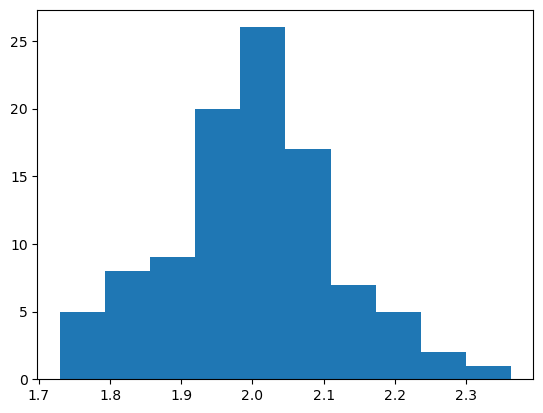

In [6]:
##ANSWER##
# print('mean of beta0:', np.mean(beta0_list))
# Notice that the mean is close to 2, which is the value of beta0 in the function we used to generate the data

print('mean of beta0:', np.mean(beta0_list))
print('std dev of beta0:', np.std(beta0_list))
plt.hist(beta0_list)
# plt.hist(beta0_list)

<Axes: ylabel='Count'>

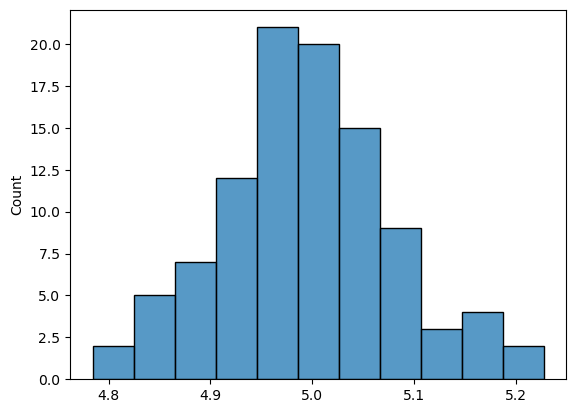

In [7]:
##ANSWER##
sns.histplot(data=beta1_list)

mean of beta1: 4.992798797704748
std dev of beta1: 0.0844965149743403


(array([ 2.,  6., 11., 15., 24., 20., 12.,  3.,  5.,  2.]),
 array([4.78454833, 4.8288393 , 4.87313026, 4.91742123, 4.96171219,
        5.00600316, 5.05029412, 5.09458509, 5.13887605, 5.18316702,
        5.22745799]),
 <BarContainer object of 10 artists>)

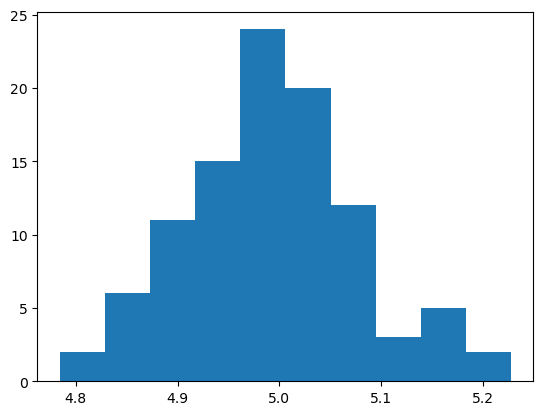

In [8]:
##ANSWER##
# Notice that the mean is approximately the choice of $beta_0$ above

print('mean of beta1:', np.mean(beta1_list))
print('std dev of beta1:', np.std(beta1_list))

plt.hist(beta1_list)


## Variance in estimation

Now let's figure out the variance of the linear regression estimates. First off, we know that $\sigma^2 = \mathrm{Var}(\varepsilon) = 1$, but let's pretend we didn't make up our own fake data. 


In [9]:
# Start with a single linear regression model
reg = LinearRegression()
reg.fit(X,y)
print( 'y = '+ str(round(reg.intercept_[0],4)) +' + ' + str(round(reg.coef_[0,0],4)) +  " * x_1"  )

y = 2.0887 + 4.887 * x_1



We can estimate $\sigma$ using residual standard error:

$$
\mathrm{RSE} = \sqrt{\mathrm{RSS}/(n-2)}
$$

In [12]:
predicted = reg.predict(X)
residuals = y - predicted

RSS = np.sum(residuals**2)
RSE = np.sqrt(RSS/(len(y)-2))
print(f"RSE = {RSE}")

RSE = 1.0465731301872223


Then the following code can compute the standard error of each coefficient

In [11]:
# We're estimating sigma^2 by RSE^2
sigma_sq = RSE**2

# We have n = 100 data points
n = 100

# We can calculate the standard error of beta_0 and beta_1 using the formulas we learned in class
x_bar = np.mean(X)
denom = np.sum((X - x_bar)**2)
beta0_var = sigma_sq * (1/n + x_bar**2/denom)
SE_beta0 = np.sqrt(beta0_var)
print(f"Standard error of beta0: {SE_beta0}")


beta1_var = sigma_sq/denom
SE_beta1 = np.sqrt(beta1_var)
print(f"Standard error of beta1: {SE_beta1}")


Standard error of beta0: 0.10510798466266061
Standard error of beta1: 0.08989557022951068


While we had to work a bit to get this to write out the standard errors, we can use the `statsmodels` library instead of `sklearn` to get these values directly.

In [13]:
import statsmodels.formula.api as smf
mydata = pd.DataFrame({'X':X.flatten(), 'y':y.flatten()})
linreg_smf = smf.ols('y ~ X', data = mydata).fit()
# linreg_smf.summary()
linreg_smf.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.0887,0.105,19.872,0.000,1.880,2.297
X,4.8870,0.090,54.363,0.000,4.709,5.065


&#9989; **<font color=red>Q:</font>** What is $SE(\hat \beta_0)$ and $SE(\hat \beta_1)$? Are they the same as what we calculated above?

Your answer here. 

![Stop Icon](https://upload.wikimedia.org/wikipedia/commons/thumb/1/1e/Vienna_Convention_road_sign_B2a.svg/180px-Vienna_Convention_road_sign_B2a.svg.png)

Great, you got to here! Hang out for a bit, there's more lecture before we go on to the next portion. 

------
## 2. Assessing Coefficient Estimate Accuracy
### The Dataset

We will be using the `Diabetes` data set again, which you looked into from the last class. In case you've forgotten, there is information about the data set [in the documentation](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).

In [14]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
diabetes_df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
diabetes_df['target'] = pd.Series(diabetes.target)

diabetes_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0



Like last time, we're now going to fit to a simple linear regression to the models
$$
\texttt{target} = \beta_0 + \beta_1 \cdot\texttt{s1}
$$
and 
$$
\texttt{target} = \beta_0 + \beta_1 \cdot\texttt{s5}
$$
where the variables are 
- $\texttt{s1}$: tc, total serum cholesterol

- $\texttt{s5}$: ltg, possibly log of serum triglycerides level. 

Let's start by looking at using `s5` to predict `target`.




Just for completeness, here's our code to do linear regression from last time using `sklearn`. 

In [15]:
from sklearn.linear_model import LinearRegression


# sklearn actually likes being handed numpy arrays more than 
# pandas dataframes, so we'll extract the bits we want and just pass it that. 
X = diabetes_df['s5'].values
X = X.reshape([len(X),1])
y = diabetes_df['target'].values
y = y.reshape([len(y),1])

# This code works by first creating an instance of 
# the linear regression class
reg = LinearRegression()
# Then we pass in the data we want it to use to fit.
reg.fit(X,y)

# and we can get the coefficients we want out of the model from the following code.

print(reg.coef_)
print(reg.intercept_)

# I can do some fancy printing if I really want to
lineString = str(round(reg.coef_[0,0],4)) +  "x_1 + " +  str(round(reg.intercept_[0],4))
print( 'y = ', lineString)

[[916.13737455]]
[152.13348416]
y =  916.1374x_1 + 152.1335


However today we're interested in statistical tests so we'll be using the `statsmodel` package. It has more options for statistical tests when available, however it has fewer models available which is why we will using a bit of both in this class. 

In [16]:
import statsmodels.formula.api as smf


**<font color=red>Instructor note:</font>** There is a difference in here where the book uses 
```python
import statsmodels.api as sm
model = sm.OLS(y, X)
```
which has some weird stuff with needing to include an intercept column and such. On homework problems and the like you can use this code or follow the book, either is acceptable. 

In [17]:
# Notice that the code is intentially written to look
# more like R than like python, but it still works!
# Double check..... the coefficients here should be
# about the same as those found by scikit-learn
est = smf.ols('target ~ s5', diabetes_df).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,152.1335,3.027,50.263,0.000,146.185,158.082
s5,916.1374,63.634,14.397,0.000,791.072,1041.202


&#9989; **<font color=red>Q:</font>** What is $SE(\hat \beta_0)$ and $SE(\hat \beta_1)$?

Your answer here. 

##ANSWER##
They're in the `std err` column

&#9989; **<font color=red>Q:</font>** If we instead use `s1` to predict the target, are $SE(\hat \beta_0)$ and $SE(\hat \beta_1)$ higher or lower than what you found for the `s5` prediction? Is this reasonable? Try plotting your predictions against scatter plots of the data to compare. 

In [46]:
# Your code here. 

In [18]:
##ANSWER## 
est2 = smf.ols('target ~ s1', diabetes_df).fit()
est2.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,152.1335,3.588,42.405,0.000,145.082,159.185
s1,343.2545,75.426,4.551,0.000,195.015,491.494


##ANSWER##
The error is a bit higher for both, more so for $\hat \beta_1$.

<Axes: xlabel='s5', ylabel='target'>

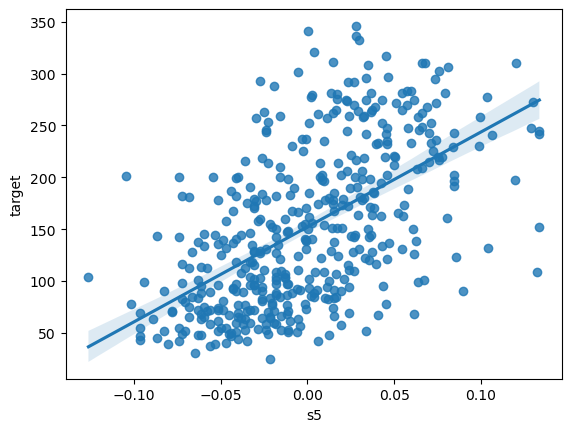

In [19]:
##ANSWER## 
sns.regplot(x = diabetes_df.s5,y = diabetes_df.target)


<Axes: xlabel='s1', ylabel='target'>

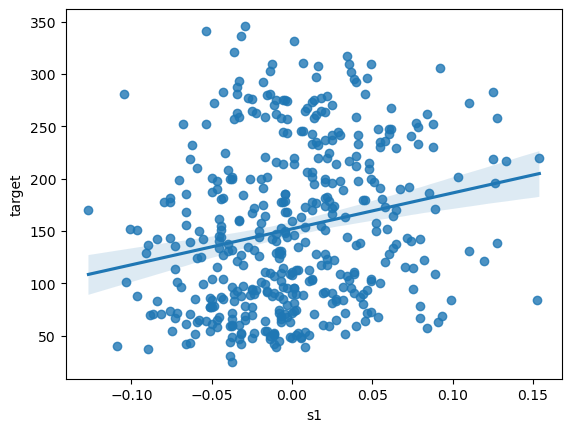

In [20]:
##ANSWER## 
sns.regplot(x = diabetes_df.s1,y = diabetes_df.target)

# Higher error for the slope makes sense because we're 
# looking at less linear data. 

&#9989; **<font color=red>Q:</font>** What are the confidence intervals for  $\hat \beta_1$ in the two cases (the prediction using `s1` and the prediction using `s5`)? Which is wider and why? 

*Hint: Check out the `est.conf_int` command or you can find this in the summary tables you've been using earlier.*

Your answer here. 

In [26]:
##ANSWER##

# print('s5')
est = smf.ols('target ~ s5', diabetes_df).fit()
print(est.conf_int(alpha=0.05))

print('\n')

# print('s1')
est2 = smf.ols('target ~ s1', diabetes_df).fit()
print(est2.conf_int(alpha=0.05))

                    0            1
Intercept  146.184753   158.082215
s5         791.072464  1041.202285


                    0           1
Intercept  145.082441  159.184528
s1         195.014752  491.494152


&#9989; **<font color=red>Q:</font>** What is the conclusion of the hypothesis test

$$H_0: \text{ There is no relationship between $X$ and $Y$}$$

$$H_a: \text{ There is some relationship between $X$ and $Y$}$$

at a confidence level of $\alpha = 0.05$?

*Your answer here*

In [21]:
##ANSWER## 
# answer is in the table given as the p-value. In this case, 
# it's so small it's basically 0 in all cases 
# This means we reject the null hypothesis
est.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,152.1335,3.027,50.263,0.000,146.185,158.082
s5,916.1374,63.634,14.397,0.000,791.072,1041.202


Oh hey look, there's another table with information stored by the statsmodel class. 

In [22]:
est.summary().tables[0]

Dep. Variable:,target,R-squared:,0.320
Model:,OLS,Adj. R-squared:,0.319
Method:,Least Squares,F-statistic:,207.3
Date:,"Tue, 02 Sep 2025",Prob (F-statistic):,8.83e-39
Time:,16:20:19,Log-Likelihood:,-2461.9
No. Observations:,442,AIC:,4928.
Df Residuals:,440,BIC:,4936.
Df Model:,1,,
Covariance Type:,nonrobust,,


&#9989; **<font color=red>Q:</font>** What is $R^2$ for the two models?

*Your answer here*

In [23]:
##ANSWER##
# We can get the R^2 value in the top right of this table
est2.summary().tables[0]

Dep. Variable:,target,R-squared:,0.045
Model:,OLS,Adj. R-squared:,0.043
Method:,Least Squares,F-statistic:,20.71
Date:,"Tue, 02 Sep 2025",Prob (F-statistic):,6.92e-06
Time:,16:20:22,Log-Likelihood:,-2537.0
No. Observations:,442,AIC:,5078.
Df Residuals:,440,BIC:,5086.
Df Model:,1,,
Covariance Type:,nonrobust,,




-----
### Congratulations, we're done!

Written by Dr. Liz Munch, adapted by Dr. Mengsen Zhang, Michigan State University
<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [24]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 
from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)


<IPython.core.display.Javascript object>

Myfilename CMSE381-002-Lec05-MoreLinReg-INSTRUCTOR.ipynb


CMSE381-002_Lec05_MoreLinReg.ipynb


Validating Notebook ./CMSE381-002_Lec05_MoreLinReg.ipynb


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: Image LINK not found - http://creativecommons.org/licenses/by-nc/4.0/


2